In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn
from sklearn.metrics import classification_report

In [3]:
DATA_DIR = "."

def read_idx_images(path):
    with open(path, "rb") as f:
        magic, n, rows, cols = np.frombuffer(f.read(16),dtype=">i4")
        data = np.frombuffer(f.read(),dtype=np.uint8)
    return data.reshape(n, rows, cols)


def read_idx_labels(path):
    with open(path, "rb") as f:
        magic, n = np.frombuffer(f.read(8),dtype=">i4")
        data = np.frombuffer(f.read(),dtype=np.uint8)
    return data.reshape(n,)

## Montar os caminhos

In [4]:
train_images_path = os.path.join(DATA_DIR, "train-images.idx3-ubyte")
train_labels_path = os.path.join(DATA_DIR, "train-labels.idx1-ubyte")

test_images_path = os.path.join(DATA_DIR, "t10k-images.idx3-ubyte")
test_labels_path = os.path.join(DATA_DIR, "t10k-labels.idx1-ubyte")

## Carregar os dados

In [5]:
x_train = read_idx_images(train_images_path)
y_train = read_idx_labels(train_labels_path)
x_test = read_idx_images(test_images_path)
y_test = read_idx_labels(test_labels_path)

## Ver uma amostra

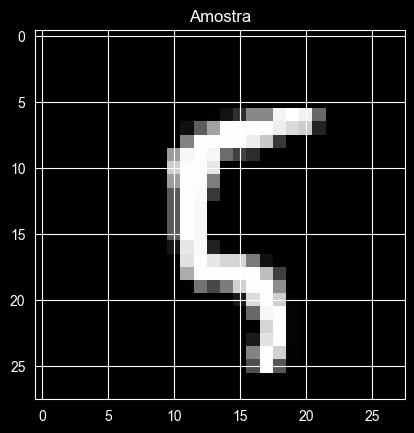

In [6]:
idx = 100
plt.figure()
plt.imshow(x_train[idx], cmap="gray")
plt.title("Amostra")
plt.show()

## Ver a matriz

In [7]:
idx = 300
matriz = x_train[idx].squeeze()
print(matriz)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 138 238
  217  68   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 150 254 254
  254 232   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  63 224 254 145
  254 240  22   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  15 160 253 25

## Pré-processamento

In [8]:
x_train = (x_train.astype("float32")/255.0)[...,None]
x_test = (x_test.astype("float32")/255.0)[...,None]
y_train_oh = tf.keras.utils.to_categorical(y_train,10)
y_test_oh = tf.keras.utils.to_categorical(y_test,10)

## Criação do modelo

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16,3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32,3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

## Compila definindo o Loss e métrica de avaliação

In [11]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

## Treino da CNN

In [ ]:
history = model.fit(
    x_train, y_train_oh,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=2
)

Epoch 1/10
422/422 - 9s - loss: 0.0107 - accuracy: 0.9964 - val_loss: 0.0512 - val_accuracy: 0.9880 - 9s/epoch - 20ms/step
Epoch 2/10
422/422 - 8s - loss: 0.0088 - accuracy: 0.9971 - val_loss: 0.0452 - val_accuracy: 0.9902 - 8s/epoch - 19ms/step
Epoch 3/10
422/422 - 8s - loss: 0.0075 - accuracy: 0.9974 - val_loss: 0.0488 - val_accuracy: 0.9893 - 8s/epoch - 20ms/step
Epoch 4/10
422/422 - 9s - loss: 0.0063 - accuracy: 0.9978 - val_loss: 0.0491 - val_accuracy: 0.9898 - 9s/epoch - 20ms/step
Epoch 5/10
422/422 - 8s - loss: 0.0056 - accuracy: 0.9984 - val_loss: 0.0494 - val_accuracy: 0.9903 - 8s/epoch - 18ms/step
Epoch 6/10
422/422 - 8s - loss: 0.0053 - accuracy: 0.9983 - val_loss: 0.0502 - val_accuracy: 0.9910 - 8s/epoch - 19ms/step
Epoch 7/10
422/422 - 9s - loss: 0.0065 - accuracy: 0.9978 - val_loss: 0.0550 - val_accuracy: 0.9897 - 9s/epoch - 20ms/step
Epoch 8/10
422/422 - 8s - loss: 0.0047 - accuracy: 0.9984 - val_loss: 0.0548 - val_accuracy: 0.9898 - 8s/epoch - 19ms/step
Epoch 9/10
422/4

## Apresentar o resultado do modelo

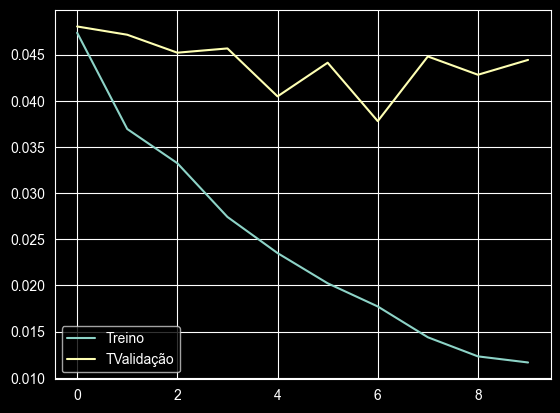

In [16]:
plt.plot(history.history["loss"],label="Treino")
plt.plot(history.history["val_loss"],label="TValidação")
plt.legend()